In [46]:
import numpy as np
import random as rand
import matplotlib.pyplot as plt
import itertools
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
import os
import json
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
models_path = os.path.join(project_root, "Models")
sys.path.append(models_path)
from ELO import Elo

In [47]:
# Get project root (2 levels up from current notebook location)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
 
# Define key directories
models_dir = os.path.join(project_root, 'Models')
trained_models_dir = os.path.join(project_root, 'Trained_Models')
simulated_data_dir = os.path.join(project_root, 'Simulated_Data')
results_dir = os.path.join(project_root, 'Results')
 
# Add Models to Python path
if models_dir not in sys.path:
    sys.path.insert(0, models_dir)
 
# Verify paths exist
print("=" * 60)
print("PROJECT PATHS VERIFICATION")
print("=" * 60)
print(f"Project Root:      {project_root}")
print(f"Models Dir:        {models_dir} ✓" if os.path.exists(models_dir) else f"Models Dir:        {models_dir} ✗")
print(f"Trained Models:    {trained_models_dir} ✓" if os.path.exists(trained_models_dir) else f"Trained Models:    {trained_models_dir} ✗")
print(f"Simulated Data:    {simulated_data_dir} ✓" if os.path.exists(simulated_data_dir) else f"Simulated Data:    {simulated_data_dir} ✗")
print(f"Results Dir:       {results_dir} ✓" if os.path.exists(results_dir) else f"Results Dir:       {results_dir} ✗")
print("=" * 60)

PROJECT PATHS VERIFICATION
Project Root:      /Users/GraceCeline/Bachelorarbeit
Models Dir:        /Users/GraceCeline/Bachelorarbeit/Models ✓
Trained Models:    /Users/GraceCeline/Bachelorarbeit/Trained_Models ✓
Simulated Data:    /Users/GraceCeline/Bachelorarbeit/Simulated_Data ✓
Results Dir:       /Users/GraceCeline/Bachelorarbeit/Results ✓


In [48]:
def load_testing_data(scenario, split):
    base_path = os.path.join(project_root, 'Simulated_Data')
    
    filename = f"scenario_{scenario}_{split}_data.csv"
    filepath = os.path.join(base_path, filename)
    
    return pd.read_csv(filepath)

In [49]:
def construct_training_data(df, initial_id, last_id, num_task):
    X = []
    Y = []

    task_ids    = sorted(df['task'].unique())
    task_to_idx = {task: idx for idx, task in enumerate(task_ids)}

    for student_id in range(initial_id, last_id):
        student_df = df[df['student_id'] == student_id].reset_index(drop=True)
        X_student = [torch.zeros(num_task * 2)] 
        Y_student = []

        for _, row in student_df.iterrows():
            task_id = row['task']
            success = row['success']
            y_student = torch.tensor([int(task_id), float(success)])
            Y_student.append(y_student)

            x_student = torch.zeros(num_task *2)
            if success == 1:
                x_student[task_id] = 1
            else:
                x_student[task_id + num_task] = 1
            X_student.append(x_student)
        
        X_student = torch.stack(X_student)
        Y_student = torch.stack(Y_student)
        X.append(X_student)
        Y.append(Y_student)

    return X, Y


In [50]:
import torch
import random

class DKTplus(torch.nn.Module):
    def __init__(self, num_exercises, num_neurons = 32, C = 1000., num_epochs = 5000, learning_rate = 1E-2):
        super(DKTplus, self).__init__()
        self.num_exercises_ = num_exercises
        self.num_neurons_   = num_neurons
        self.C_             = C
        self.num_epochs_    = num_epochs
        self.learning_rate_ = learning_rate
        self.gru_           = torch.nn.GRU(self.num_exercises_ * 2, self.num_neurons_) # this is f
        self.out_           = torch.nn.Linear(self.num_neurons_, self.num_exercises_) # this is g

    def forward(self, X):
        H, _ = self.gru_(X)
        return self.out_(H)

    """
    Scores the accuracy of this model.
    """
    def score(self, X, Y):
        num_attempts  = 0
        num_successes = 0
        for i in range(len(X)):
            Yi = Y[i]
            Logits = self.forward(X[i])
            selected_logits = Logits.gather(
                                  1, Yi[:,0].long().unsqueeze(1)
                              ).squeeze(1)
            probs = torch.sigmoid(selected_logits)
            preds = (probs >= 0.5).float()

            num_successes += (preds == Yi[:,1]).sum().item()
            num_attempts += len(Yi[:,1])
        return num_successes / num_attempts
    
    def reconstruction_term(self, Logits, Yi):
        # Logits[t] is produced right after the model consumes X[t],
        # which one-hot-encodes Yi[t-1]. So Logits[1:] reconstructs Yi[:] elementwise.
        recon_logits = Logits[1:]                    # (T, M) — drop the row from the dummy input
        ids  = Yi[:, 0].long()
        ans  = Yi[:, 1].float()
        selected_logits = recon_logits.gather(1, ids.unsqueeze(1)).squeeze(1)
        return torch.nn.functional.binary_cross_entropy_with_logits(selected_logits, ans)
    
    @torch.no_grad()
    def waviness(self, X):
        self.eval()
        total_l1 = 0.0
        total_l2 = 0.0
        total_denom = 0.0
        for Xi in X:
            Logits = self.forward(Xi)
            w1, w2_sq = self.waviness_terms(Logits)
            n = (Logits.shape[0] - 1) * Logits.shape[1]
            total_l1 += w1.item() * n
            total_l2 += w2_sq.item() * n
            total_denom += n
        self.train()
        return total_l1 / total_denom, (total_l2 / total_denom) ** 0.5

    def waviness_terms(self, Logits):
        probs = torch.sigmoid(Logits)          # (T, M)
        diff  = probs[1:] - probs[:-1]         # (T-1, M)
        M  = probs.shape[1]
        Tm1 = diff.shape[0]
        w1     = diff.abs().sum() / (M * Tm1)
        w2_sq  = (diff ** 2).sum() / (M * Tm1)   # this is w2^2 as in eq. 7; take sqrt if you want w2 itself
        return w1, w2_sq

    """
    Fits this model to the given data matrix.

    Parameters
    ----------
    X: list
        A list of feature matrices, one per student.
    Y: list
        A list of target matrices, one per student.

    """
    def fit(self, X, Y, lambda_r=0.0, lambda_w1=0.0, lambda_w2=0.0):
        # initialize optimizer
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate_, weight_decay = 1. / self.C_)
        self.train()
        # start training
        for epoch in range(self.num_epochs_):
            # re-set the current gradient to zero
            optimizer.zero_grad()
            # get a random student index
            i  = random.randrange(len(X))
            Xi = X[i]
            Yi = Y[i]
            # compute the Logits
            Logits = self.forward(Xi)
            selected_logits = Logits.gather(
                                  1, Yi[:,0].long().unsqueeze(1)
                              ).squeeze(1) # Choose the index of the executed task, and only take the logit of this task for every time step
            # compute the loss
            w1, w2_sq = self.waviness_terms(Logits)
            loss = torch.nn.functional.binary_cross_entropy_with_logits(selected_logits, Yi[:,1].float())
            r = self.reconstruction_term(Logits, Yi)
            regularized_loss = loss + lambda_r * r + lambda_w1 * w1 + lambda_w2 * w2_sq

            # report the loss
            # if (epoch+1) % 1000 == 0:
                # print('epoch %d: loss %g' % (epoch+1, loss.item()))
            # compute the gradient
            regularized_loss.backward()
            # apply the optimizer
            optimizer.step()

        return self
    

In [51]:
def load_model(scenario_id, num_exercises, base_dir=None, device=None):
    """
    Load a saved DKT+ model checkpoint for testing.

    Args:
        scenario_id   : scenario identifier (e.g. 1–6, or a string name)
        num_exercises : number of tasks/exercises (must match training)
        base_dir      : optional override for the Trained_Models folder path
        device        : torch.device to load onto ('cpu', 'cuda', etc.)
                        defaults to cuda if available, else cpu

    Returns:
        model       : DKTplus model in eval() mode, ready for inference
        checkpoint  : full checkpoint dict (contains hyperparams + lambdas)
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    if base_dir is None:
        base_dir = os.path.join(project_root, 'Trained_Models')

    model_path = os.path.join(base_dir, f'DKTplus_model_scenario_{scenario_id}.pth')

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"No saved model found for scenario {scenario_id} at:\n  {model_path}")

    checkpoint = torch.load(model_path, map_location=device)

    # Rebuild the architecture from saved constructor args
    model = DKTplus(
        num_exercises = num_exercises,
        num_neurons   = checkpoint['num_neurons'],
        C             = checkpoint['C'],
        num_epochs    = checkpoint['num_epochs'],
        learning_rate = checkpoint['learning_rate'],
    )

    # Load the trained weights
    model.load_state_dict(checkpoint['model_state'])
    model.to(device)
    model.eval()  # Set model to evaluation mode

    return model, checkpoint

In [52]:
def skill_display(optimal_skills):
    x_values = list(range(1, len(optimal_skills) + 1))
    # Convert data for plotting: organize skill levels into separate lists for each skill
    paired_lists = [
        [optimal_skills[j][i] for j in range(len(optimal_skills))]
        for i in range(len(optimal_skills[0]))
        ]
    num_lines = len(paired_lists) # Number of skills to plot
    colors = plt.cm.viridis(np.linspace(0, 1, num_lines)) # Generate a color palette
    plt.figure(figsize=(8, 4))
    plt.title("Highest learning gain")
    # Plot each skill level over time
    for i in range(num_lines):
        plt.plot(paired_lists[i], linestyle='-', color=colors[i], label=f'Skill {i+1}')

    plt.xlabel('Time')
    plt.ylabel('Skill Level')
    plt.legend()
    plt.grid(True)
    plt.show()

In [53]:
def calculate_p_op(n):
    return 0.5 - 1 / (2 * (n - 1))
    # Let n be the ratio of k_success and k_fail

In [54]:
def steps_to_mastery(X, Y, dkt_model, initial_skill, q_matrix, difficulty, depends, k_success, k_fail, p_op): 
    results_dkt = [] 
    DKT_Data = [] 
    
    for i in range(len(X)): 
        skill_levels = initial_skill.copy() # reset per student 
        X_student = torch.zeros((1, num_tasks * 2), dtype=torch.float32) 
        reached_step = None 
        step = 0 
        data_for_student = [] 
        skill_history = [initial_skill.tolist()] 
        
        while np.any(skill_levels <= 1.5) and step < 30: # ← safety cap 
            step += 1 
            with torch.no_grad(): 
                prob = torch.sigmoid(dkt_model(X_student))[-1] 
            uncertainty = torch.abs(prob - p_op) 
            task = torch.argmin(uncertainty).item() 
            updated_skill, correctness = Elo.skill_update( difficulty[task], skill_levels, q_matrix[:, task], depends, k_success, k_fail ) 
            skill_levels = updated_skill 
            skill_history.append(skill_levels.tolist()) 
            data_for_student.append((task, correctness)) 
            new_row = torch.zeros((1, num_tasks * 2), dtype=torch.float32) 
            if correctness == 1: 
                    new_row[0, task] = 1.0 
            else: 
                    new_row[0, task + num_tasks] = 1.0 
            X_student = torch.cat([X_student, new_row]) 
            
            if reached_step is None and np.all(skill_levels >= 1.5): 
                reached_step = step 
                
        results_dkt.append({ "student": i + 1, "steps_to_mastery": reached_step}) 
        DKT_Data.append(data_for_student) 
        last_skill_history = skill_history 
    average_steps = pd.DataFrame(results_dkt)["steps_to_mastery"].mean() 
    std_steps = pd.DataFrame(results_dkt)["steps_to_mastery"].std()
    skill_history_array = np.array(last_skill_history) 
    return average_steps, std_steps, skill_history_array

In [55]:
def optimized_steps_to_mastery(X, Y, dkt_model, num_tasks, initial_skill, q_matrix, difficulty, depends, k_success, n): # n is ratio from k+ to k-
    results_dkt      = []
    DKT_Data         = []
    k_fail = 1/n
    p_op = calculate_p_op(n)
    print(f"Adjusted kappa with k- being {k_fail}")

    for i in range(len(X)):
        skill_levels     = initial_skill.copy()   # reset per student
        X_student        = torch.zeros((1, num_tasks * 2), dtype=torch.float32)
        reached_step     = None
        step             = 0
        data_for_student = []
        skill_history    = [initial_skill.tolist()]

        while np.any(skill_levels <= 1.5) and step < 30:  # ← safety cap
            step += 1

            with torch.no_grad():
                prob      = torch.sigmoid(dkt_model(X_student))[-1]
            uncertainty   = torch.abs(prob - p_op)
            task          = torch.argmin(uncertainty).item()

            updated_skill, correctness = Elo.skill_update(
                difficulty[task], skill_levels, q_matrix[:, task], depends, k_success, k_fail
            )

            if i == 0:
                print(f"[Student 0]: Selected Task {task} Knowledge state: {updated_skill}, Response: {correctness}")
            skill_levels = updated_skill
            skill_history.append(skill_levels.tolist())
            data_for_student.append((task, correctness))

            new_row = torch.zeros((1, num_tasks * 2), dtype=torch.float32)
            if correctness == 1:
                new_row[0, task] = 1.0
            else:
                new_row[0, task + num_tasks] = 1.0
            X_student = torch.cat([X_student, new_row])

            if reached_step is None and np.all(skill_levels >= 1.5):
                reached_step = step

        results_dkt.append({
            "student":           i + 1,
            "steps_to_mastery":  reached_step,
            "p_op":         p_op
        })
        DKT_Data.append(data_for_student)
        last_skill_history = skill_history

    average_steps = pd.DataFrame(results_dkt)["steps_to_mastery"].mean()
    std_steps = pd.DataFrame(results_dkt)["steps_to_mastery"].std()
    skill_history_array = np.array(last_skill_history)
    return average_steps, std_steps, skill_history_array, p_op

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_optimization(num_tasks):
    n_values = [2, 4, 6]
    results = []
    plot_data_by_n = {}
    all_rows = []
    row = {"scenario": scenario_id}
    # Test each n value
    for n in n_values:
        # Get optimal p_op
        avg_steps_opt, std_steps_opt, rand_plot_opt, p_op_opt = optimized_steps_to_mastery(
            X_test, Y_test, dktplus, num_tasks, init_skill_level.copy(), 
            q_matrix, difficulty_level, depends, 1, n
        )

        p_op_label = round(p_op_opt, 2)
        row[f"p_op_{p_op_label}_mean"] = avg_steps_opt
        row[f"p_op_{p_op_label}_std"]  = std_steps_opt

        # Test p_op = 0.25
        avg_steps_00, std_steps_00, rand_plot_00 = steps_to_mastery(
            X_test, Y_test, dktplus, init_skill_level.copy(), 
            q_matrix, difficulty_level, depends, 1, 1/n, 0.0
        )

        # Test p_op = 0.5
        avg_steps_05, std_steps_05, rand_plot_05 = steps_to_mastery(
            X_test, Y_test, dktplus, init_skill_level.copy(), 
            q_matrix, difficulty_level, depends, 1, 1/n, 0.5
        )
        
        # Store results for table
        results.append({
            "scenario": scenario_id,
            "n": n,
            "p_op_optimal": p_op_opt,
            "steps_optimal_mean": avg_steps_opt,
            "steps_optimal_std": std_steps_opt,
            "steps_p00_mean": avg_steps_00,
            "steps_p00_std": std_steps_00,
            "steps_p05_mean": avg_steps_05,
            "steps_p05_std": std_steps_05,
        })
        # Store plot data
        plot_data_by_n[n] = {
            "p_op_opt": p_op_opt,
            "rand_plot_opt": rand_plot_opt,
            "rand_plot_00": rand_plot_00,
            "rand_plot_05": rand_plot_05,
        }
    # Create results dataframe
    df_results = pd.DataFrame(results)
    # Save to CSV
    df_results.to_csv(f'Results/dktplus_results_scenario_{scenario_id}.csv', index=False)

    all_rows.append(row)
    pd.DataFrame(all_rows).to_csv(f"../../Results/dktplus_results_scenario_{scenario_id}.csv", index=False)
    
    # Plot 3 subplots (one for each n) - reuse stored data
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for idx, n in enumerate(n_values):
        ax = axes[idx]
        data = plot_data_by_n[n]
        
        steps_opt = range(data['rand_plot_opt'].shape[0])
        steps_00 = range(data['rand_plot_00'].shape[0])
        steps_05 = range(data['rand_plot_05'].shape[0])
        
        # Skill 0 (column 0)
        ax.plot(steps_opt, data['rand_plot_opt'][:, 0], marker='o', label=f'Optimal p_op={data["p_op_opt"]:.2f}', linewidth=2, color='blue')
        ax.plot(steps_00, data['rand_plot_00'][:, 0], marker='s', label='p_op=0.00', linewidth=2, color='orange')
        ax.plot(steps_05, data['rand_plot_05'][:, 0], marker='^', label='p_op=0.50', linewidth=2, color='purple')
        
        # Skill 1 (column 1) - dashed lines
        ax.plot(steps_opt, data['rand_plot_opt'][:, 1], marker='o', linestyle='--', linewidth=2, color='blue', alpha=0.6)
        ax.plot(steps_00, data['rand_plot_00'][:, 1], marker='s', linestyle='--', linewidth=2, color='orange', alpha=0.6)
        ax.plot(steps_05, data['rand_plot_05'][:, 1], marker='^', linestyle='--', linewidth=2, color='purple', alpha=0.6)
        
        ax.axhline(y=1.5, color='red', linestyle='--', linewidth=1.5)
        ax.set_title(f'n={n}', fontweight='bold', fontsize=12)
        ax.set_xlabel('Step')
        ax.set_ylabel('Skill Level')
        ax.legend(['Optimal (Skill 0)', 'p_op=0.00 (Skill 0)', 'p_op=0.50 (Skill 0)', 
                   'Optimal (Skill 1)', 'p_op=0.00 (Skill 1)', 'p_op=0.50 (Skill 1)', 'Mastery threshold'])
        ax.grid(True, alpha=0.3)
    
    fig.suptitle(f'DKT Task Selection Comparison — Scenario {scenario_id}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    # plt.savefig(f'dkt_results_scenario_{scenario_id}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # return df_results

# Optimize DKT

In [57]:
with open('../../elo_variable.json', 'r') as Elo_Data:
    elo_data = json.load(Elo_Data)

print(elo_data)

{'globals': {'students': 500, 'init_skill_level': [0.0, 0.0], 'k_success': 1, 'k_fail': 0.5}, 'scenarios': [{'id': 1, 'num_tasks': 2, 'num_skills': 2, 'q_matrix': [[1, 0], [0, 1]], 'difficulty_level': [1, 1], 'depends': [-1, -1]}, {'id': 2, 'num_tasks': 2, 'num_skills': 2, 'q_matrix': [[1, 1], [1, 1]], 'difficulty_level': [0, 1], 'depends': [-1, -1]}, {'id': 3, 'num_tasks': 4, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 0], [0, 1, 0, 1]], 'difficulty_level': [0, 0, 1, 1], 'depends': [-1, -1, -1, -1]}, {'id': 4, 'num_tasks': 4, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 1], [0, 1, 1, 1]], 'difficulty_level': [1, 1, 0, 1], 'depends': [-1, -1, -1, -1]}, {'id': 5, 'num_tasks': 6, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 1, 0, 1], [0, 1, 1, 0, 1, 1]], 'difficulty_level': [0, 0, 0, 1, 1, 1], 'depends': [-1, -1, -1, -1, -1, -1]}, {'id': 6, 'num_tasks': 6, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 0, 1, 0], [0, 1, 0, 1, 0, 1]], 'difficulty_level': [0, 0, 1, 1, 2, 2], 'depends': [-1, -1, -1, -1, -1, -1]}

In [58]:
all_data = {}

level_skill   = [] 
mastery_level = 1.5
i = 0

global_values = elo_data["globals"]
scenarios = elo_data["scenarios"]

students          = global_values["students"]
# init_skill_level  = np.array([0.0])

0.2 0.03 1.0
-------------- RESULTS FOR SCENARIO 1------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 1 Knowledge state: [0.         0.36552929], Response: 0
[Student 0]: Selected Task 1 Knowledge state: [0.         1.01903178], Response: 1
[Student 0]: Selected Task 0 Knowledge state: [0.36552929 1.01903178], Response: 0
[Student 0]: Selected Task 0 Knowledge state: [0.69228053 1.01903178], Response: 0
[Student 0]: Selected Task 0 Knowledge state: [0.98044479 1.01903178], Response: 0
[Student 0]: Selected Task 0 Knowledge state: [1.48533344 1.01903178], Response: 1
[Student 0]: Selected Task 1 Knowledge state: [1.48533344 1.51427398], Response: 1
[Student 0]: Selected Task 1 Knowledge state: [1.48533344 1.88846612], Response: 1
[Student 0]: Selected Task 0 Knowledge state: [1.86632694 1.88846612], Response: 1
Adjusted kappa with k- being 0.25
[Student 0]: Selected Task 0 Knowledge state: [0.18276464 0.        ], Response: 0
[St

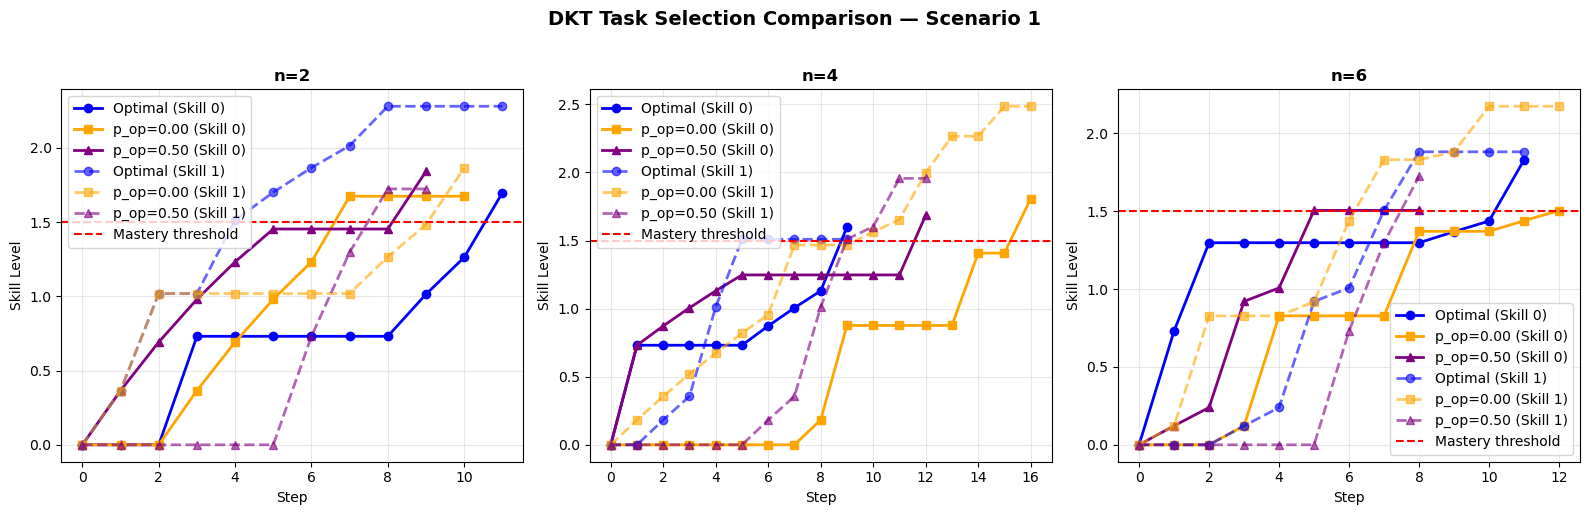

0 0.03 0.3
-------------- RESULTS FOR SCENARIO 2------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 1 Knowledge state: [0.36552929 0.36552929], Response: 0
[Student 0]: Selected Task 1 Knowledge state: [0.69228053 0.69228053], Response: 0
[Student 0]: Selected Task 1 Knowledge state: [0.98044479 0.98044479], Response: 0
[Student 0]: Selected Task 1 Knowledge state: [1.23288911 1.23288911], Response: 0
[Student 0]: Selected Task 1 Knowledge state: [1.67492857 1.67492857], Response: 1
Adjusted kappa with k- being 0.25
[Student 0]: Selected Task 0 Knowledge state: [0.125 0.125], Response: 0
[Student 0]: Selected Task 1 Knowledge state: [0.30144626 0.30144626], Response: 0
[Student 0]: Selected Task 1 Knowledge state: [0.46841302 0.46841302], Response: 0
[Student 0]: Selected Task 0 Knowledge state: [0.564661 0.564661], Response: 0
[Student 0]: Selected Task 1 Knowledge state: [0.71644796 0.71644796], Response: 0
[Student 0]: Select

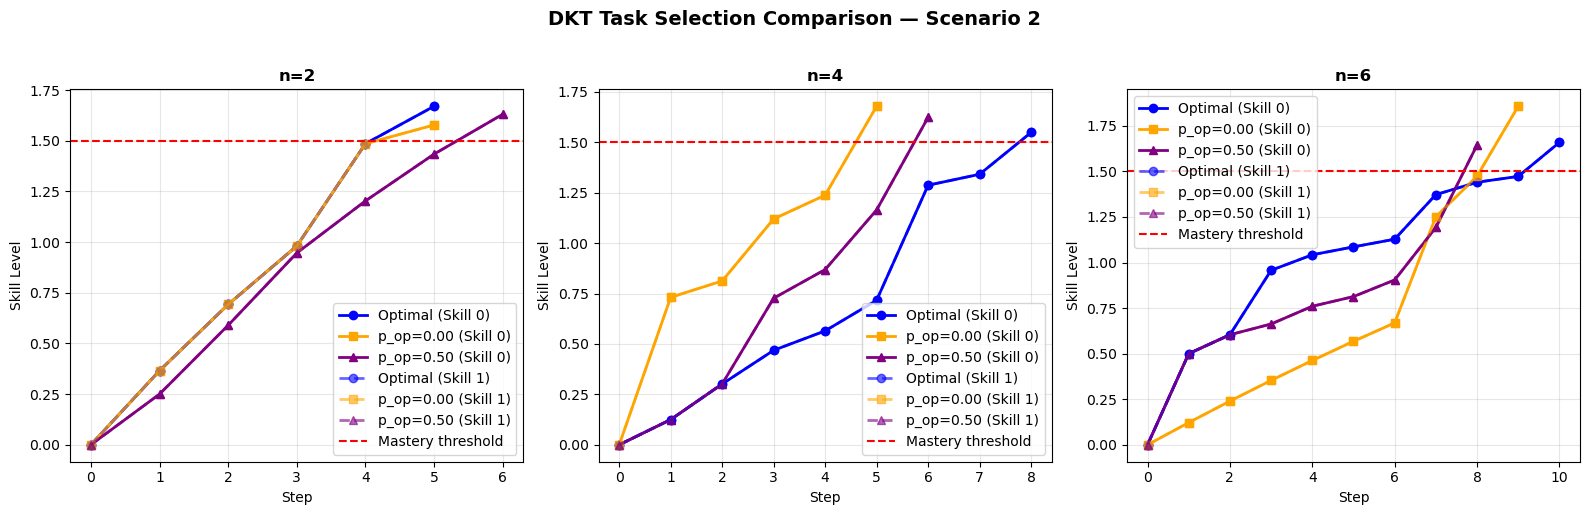

0 1.0 0.3
-------------- RESULTS FOR SCENARIO 3------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 2 Knowledge state: [0.36552929 0.        ], Response: 0
[Student 0]: Selected Task 3 Knowledge state: [0.36552929 0.36552929], Response: 0
[Student 0]: Selected Task 3 Knowledge state: [0.36552929 0.69228053], Response: 0
[Student 0]: Selected Task 3 Knowledge state: [0.36552929 0.98044479], Response: 0
[Student 0]: Selected Task 3 Knowledge state: [0.36552929 1.48533344], Response: 1
[Student 0]: Selected Task 2 Knowledge state: [1.01903178 1.48533344], Response: 1
[Student 0]: Selected Task 2 Knowledge state: [1.51427398 1.48533344], Response: 1
[Student 0]: Selected Task 3 Knowledge state: [1.51427398 1.67583019], Response: 0
Adjusted kappa with k- being 0.25
[Student 0]: Selected Task 2 Knowledge state: [0.18276464 0.        ], Response: 0
[Student 0]: Selected Task 3 Knowledge state: [0.18276464 0.18276464], Response: 0
[Stude

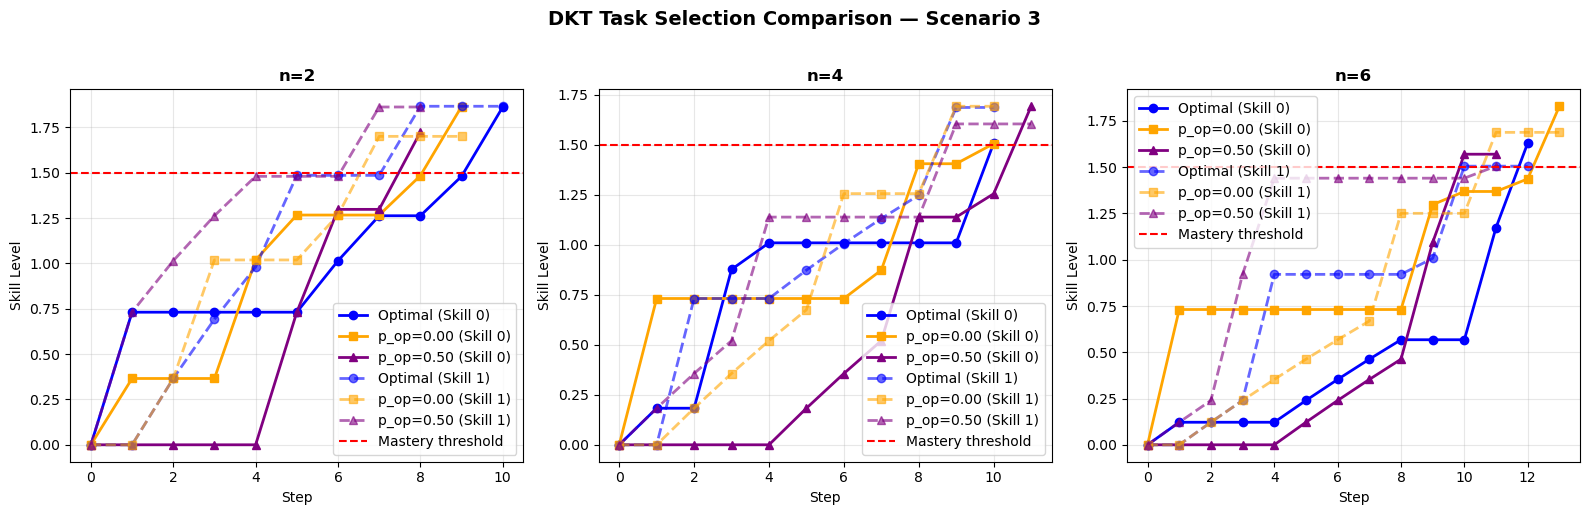

0.25 0.03 3.0
-------------- RESULTS FOR SCENARIO 4------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 3 Knowledge state: [0.36552929 0.36552929], Response: 0
[Student 0]: Selected Task 3 Knowledge state: [0.69228053 0.69228053], Response: 0
[Student 0]: Selected Task 3 Knowledge state: [0.98044479 0.98044479], Response: 0
[Student 0]: Selected Task 3 Knowledge state: [1.48533344 1.48533344], Response: 1
[Student 0]: Selected Task 2 Knowledge state: [1.66995662 1.66995662], Response: 1
Adjusted kappa with k- being 0.25
[Student 0]: Selected Task 0 Knowledge state: [0.18276464 0.        ], Response: 0
[Student 0]: Selected Task 2 Knowledge state: [0.29637354 0.125     ], Response: 0
[Student 0]: Selected Task 0 Knowledge state: [0.96536486 0.125     ], Response: 1
[Student 0]: Selected Task 1 Knowledge state: [0.96536486 0.83078503], Response: 1
[Student 0]: Selected Task 2 Knowledge state: [1.24117021 1.13426413], Response: 1
[S

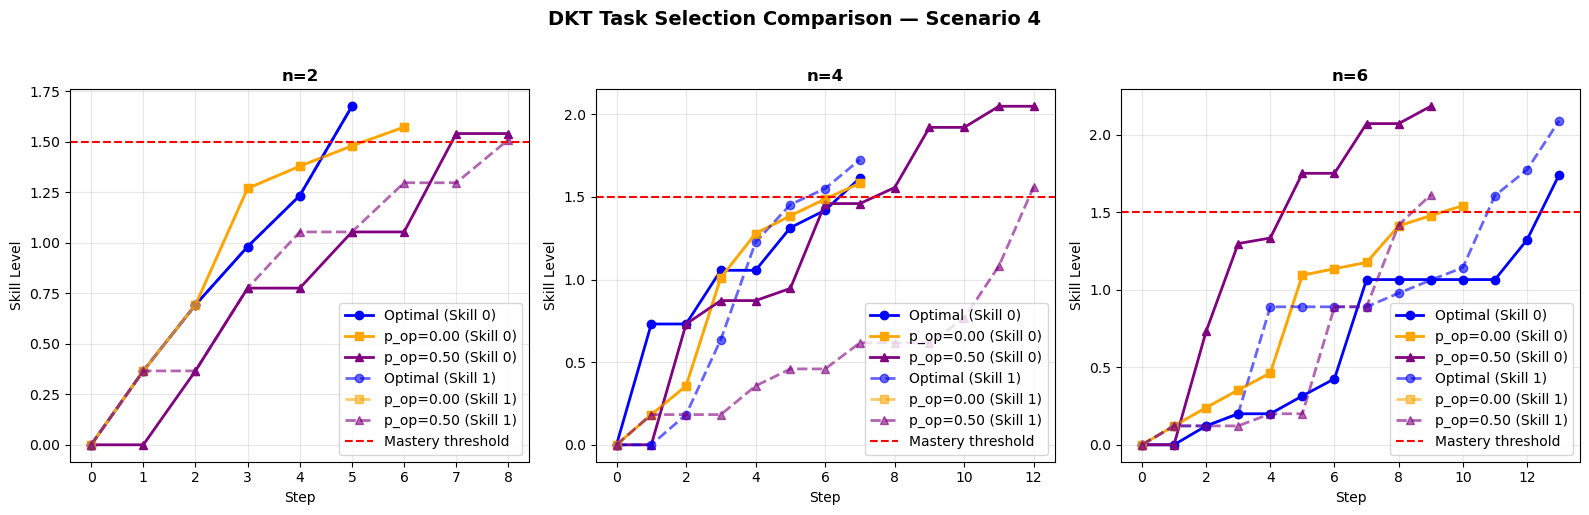

0.1 1.0 0
-------------- RESULTS FOR SCENARIO 5------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 5 Knowledge state: [0.36552929 0.36552929], Response: 0
[Student 0]: Selected Task 5 Knowledge state: [0.69228053 0.69228053], Response: 0
[Student 0]: Selected Task 5 Knowledge state: [0.98044479 0.98044479], Response: 0
[Student 0]: Selected Task 5 Knowledge state: [1.23288911 1.23288911], Response: 0
[Student 0]: Selected Task 5 Knowledge state: [1.45390884 1.45390884], Response: 0
[Student 0]: Selected Task 5 Knowledge state: [1.64812474 1.64812474], Response: 0
Adjusted kappa with k- being 0.25
[Student 0]: Selected Task 2 Knowledge state: [0.125 0.125], Response: 0
[Student 0]: Selected Task 4 Knowledge state: [0.125      0.30144626], Response: 0
[Student 0]: Selected Task 2 Knowledge state: [0.24219766 0.40774725], Response: 0
[Student 0]: Selected Task 5 Knowledge state: [0.41241676 0.56871772], Response: 0
[Student 0]: Sel

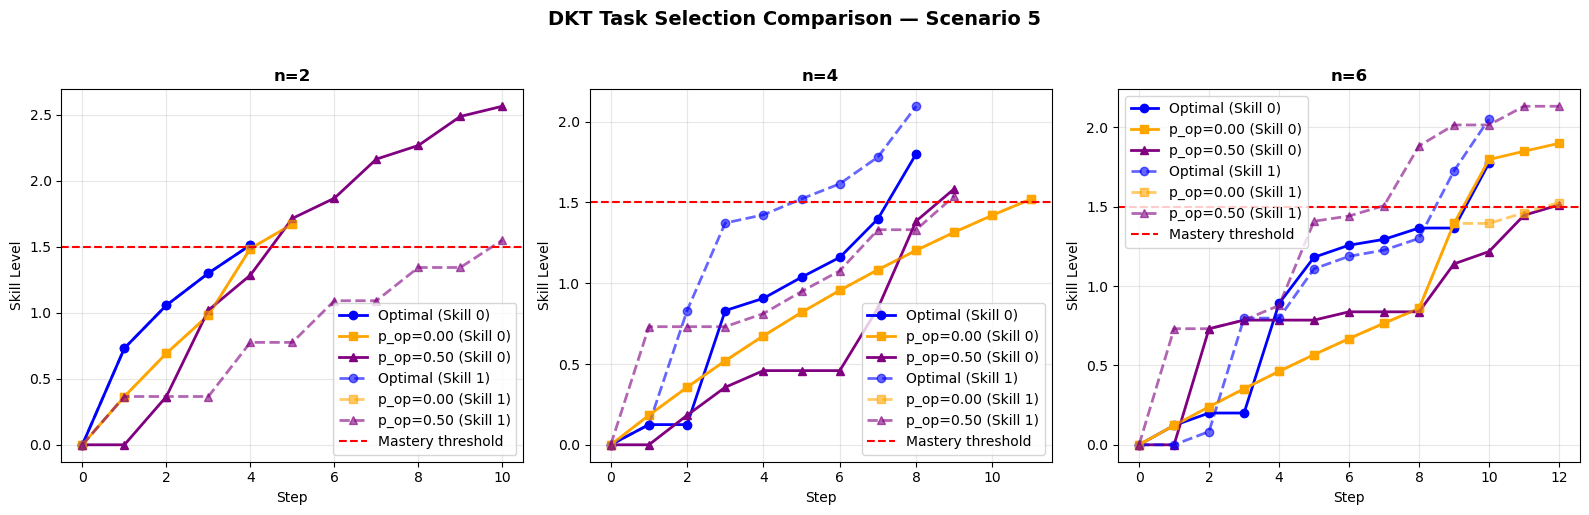

0 0.03 10.0
-------------- RESULTS FOR SCENARIO 6------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 5 Knowledge state: [0.         0.44039854], Response: 0
[Student 0]: Selected Task 5 Knowledge state: [0.        1.2666947], Response: 1
[Student 0]: Selected Task 4 Knowledge state: [0.44039854 1.2666947 ], Response: 0
[Student 0]: Selected Task 5 Knowledge state: [0.44039854 1.60445979], Response: 0
[Student 0]: Selected Task 4 Knowledge state: [1.2666947  1.60445979], Response: 1
[Student 0]: Selected Task 5 Knowledge state: [1.2666947  1.90326763], Response: 0
[Student 0]: Selected Task 4 Knowledge state: [1.60445979 1.90326763], Response: 0
Adjusted kappa with k- being 0.25
[Student 0]: Selected Task 3 Knowledge state: [0.         0.18276464], Response: 0
[Student 0]: Selected Task 3 Knowledge state: [0.         0.87641381], Response: 1
[Student 0]: Selected Task 2 Knowledge state: [0.73105858 0.87641381], Response: 1
[Stude

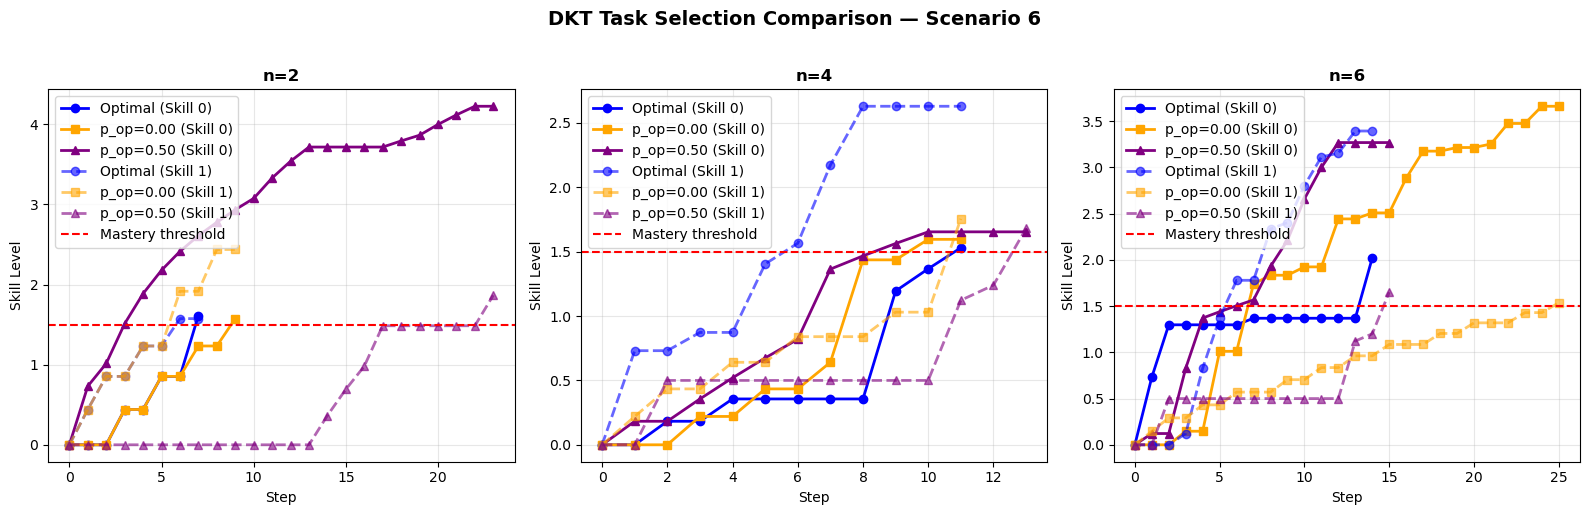

0 0.1 0.3
-------------- RESULTS FOR SCENARIO 7------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 7 Knowledge state: [0.44039854 0.44039854 0.44039854], Response: 0
[Student 0]: Selected Task 7 Knowledge state: [0.85354662 0.85354662 0.85354662], Response: 0
[Student 0]: Selected Task 7 Knowledge state: [1.23297788 1.23297788 1.23297788], Response: 0
[Student 0]: Selected Task 7 Knowledge state: [1.57441606 1.57441606 1.57441606], Response: 0
Adjusted kappa with k- being 0.25
[Student 0]: Selected Task 5 Knowledge state: [0.18276464 0.18276464 0.        ], Response: 0
[Student 0]: Selected Task 6 Knowledge state: [0.18276464 0.29637354 0.        ], Response: 0
[Student 0]: Selected Task 5 Knowledge state: [0.35617694 0.46362137 0.        ], Response: 0
[Student 0]: Selected Task 6 Knowledge state: [0.35617694 0.84974846 0.        ], Response: 1
[Student 0]: Selected Task 5 Knowledge state: [0.52008123 0.98412155 0.        ], Re

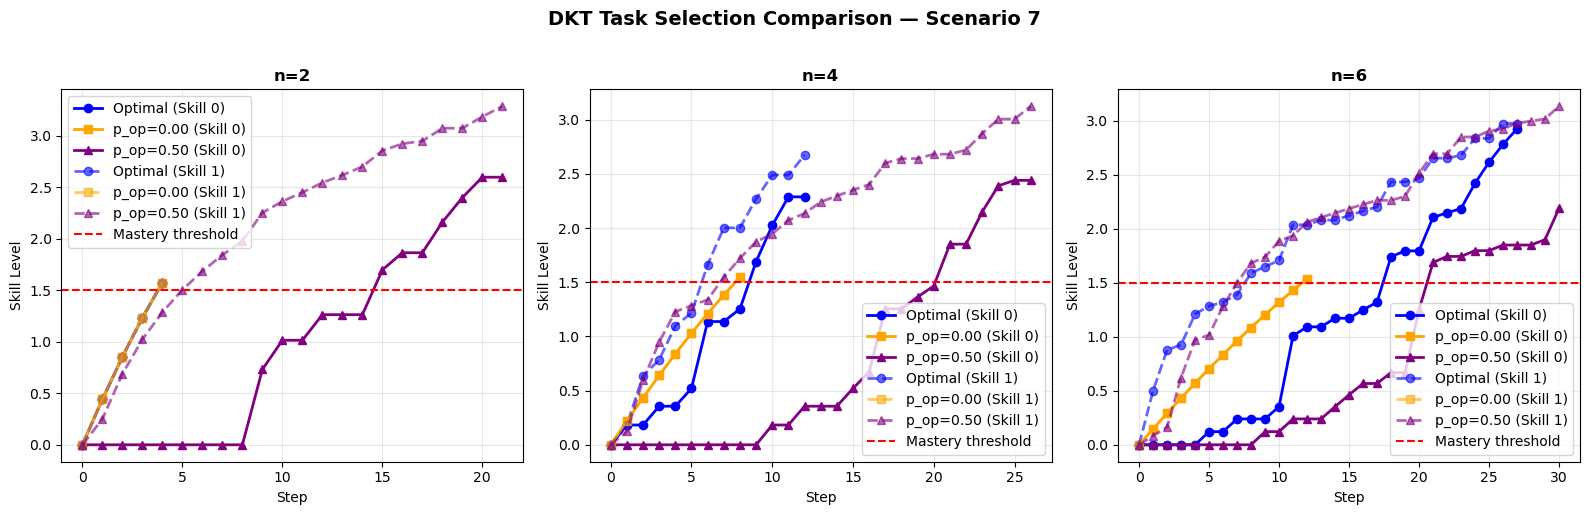

0.25 0.1 0
-------------- RESULTS FOR SCENARIO 8------------------
OPTIMIZE TASK SELECTION METHOD
Adjusted kappa with k- being 0.5
[Student 0]: Selected Task 6 Knowledge state: [0.95257413 0.        ], Response: 1
[Student 0]: Selected Task 7 Knowledge state: [0.95257413 0.47628706], Response: 0
[Student 0]: Selected Task 7 Knowledge state: [0.95257413 0.93918084], Response: 0
[Student 0]: Selected Task 7 Knowledge state: [0.95257413 1.38269898], Response: 0
[Student 0]: Selected Task 6 Knowledge state: [1.39541776 1.38269898], Response: 0
[Student 0]: Selected Task 6 Knowledge state: [1.81174668 1.38269898], Response: 0
[Student 0]: Selected Task 6 Knowledge state: [2.19496094 1.38269898], Response: 0
[Student 0]: Selected Task 6 Knowledge state: [2.54048662 1.38269898], Response: 0
[Student 0]: Selected Task 7 Knowledge state: [2.54048662 1.79991027], Response: 0
Adjusted kappa with k- being 0.25
[Student 0]: Selected Task 2 Knowledge state: [0.18276464 0.        ], Response: 0
[Stud

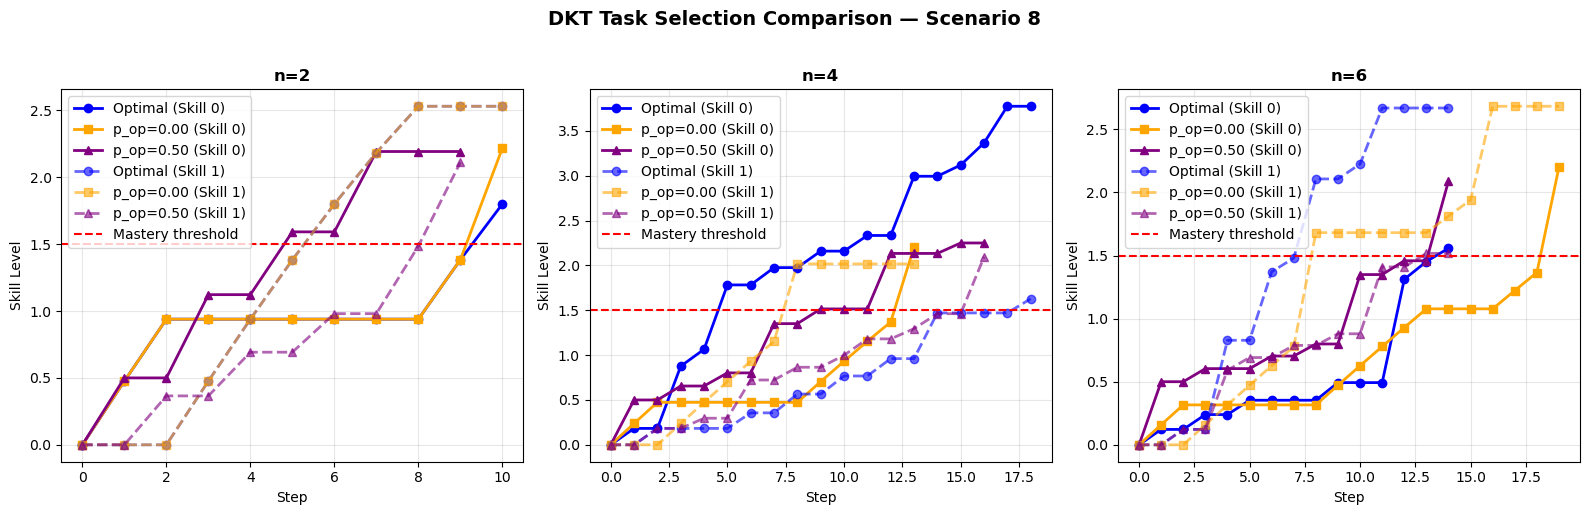

In [59]:
for scenario in scenarios:
        scenario_id    = scenario["id"]
        num_tasks      = scenario["num_tasks"]
        num_skills     = scenario["num_skills"]
        difficulty_level = np.array(scenario["difficulty_level"])
        q_matrix       = np.array(scenario["q_matrix"])
        depends = np.array(scenario["depends"])
        init_skill_level  = np.array([0.0] * num_skills)
        
        dktplus, checkpoint = load_model(scenario_id, num_tasks)
        print(checkpoint['lambda_r'], checkpoint['lambda_w1'], checkpoint['lambda_w2'])
            
        all_students_skill_dkt = []
        all_students_task_allocation_dkt = []
        
        print(f"-------------- RESULTS FOR SCENARIO {scenario_id}------------------")
        
        num_students_test = 50
        test_df = load_testing_data(scenario_id, "test")
        X_test, Y_test   = construct_training_data(test_df, 401, 450, num_tasks)
        print("OPTIMIZE TASK SELECTION METHOD")
        run_optimization(num_tasks)

# Your code here - all output will be saved to the file

In [60]:
import pandas as pd
import glob

files = sorted(glob.glob('Results/dktplus_results_scenario_*.csv'))

df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Sort nicely by scenario, then n
df_all = df_all.sort_values(['scenario', 'n']).reset_index(drop=True)
# Write as a formatted plain-text table
with open('Results/dktplus_results_combined.txt', 'w') as f:
    f.write(df_all.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print(df_all)

    scenario  n  p_op_optimal  steps_optimal_mean  steps_optimal_std  \
0          1  2      0.000000            9.428571           2.380476   
1          1  4      0.333333           12.000000           3.013857   
2          1  6      0.400000           14.061224           4.058983   
3          2  2      0.000000            5.204082           0.611678   
4          2  4      0.333333            8.285714           1.825742   
5          2  6      0.400000            9.244898           2.610321   
6          3  2      0.000000            8.836735           1.490902   
7          3  4      0.333333           10.224490           1.873781   
8          3  6      0.400000           12.448980           3.385393   
9          4  2      0.000000            5.204082           0.611678   
10         4  4      0.333333           10.163265           2.460919   
11         4  6      0.400000           12.020408           2.947384   
12         5  2      0.000000            5.306122           0.61

Most scenario still tend to re trained already mastered skill. we need amodel that stops trianing when mastery is reached. PFA does this automatically for some reason